In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Resolve repo root whether launched from repo root or Notebooks/
repo_root = Path.cwd().resolve()
if not (repo_root / "backtesting" / "renquant_201").exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root))

import common

# ── Strategy configuration ───────────────────────────────────────────────
STRATEGY_DIR = repo_root / "backtesting" / "renquant_201"
config = common.load_strategy_config(STRATEGY_DIR / "strategy_config.json")

WATCHLIST = config["watchlist"]
BENCHMARK = config.get("benchmark", "SPY")
MODEL_NAME = config["model_name"]
START = config["sample_start"]
END = config["sample_end"]
PROVIDER = config["data_src"]
MODEL_PARAMS = config["model_params"]

# Full indicator spec for research (superset of what the model uses)
INDICATOR_SPEC = {
    "rsi":         {"period": 14},
    "macd":        {"fast": 12, "slow": 26, "signal": 9},
    "cci":         {"period": 20},
    "bbp":         {"period": 20},
    "stochastic":  {"window": 14, "smooth": 3},
    "adx":         {"period": 14},
    "atr":         {"period": 14},
    "obv":         {"signal_period": 20},
    "williams_r":  {"period": 14},
    "ema":         {"period": 50},
    "momentum":    {"period": 10},
}

FEATURE_COLUMNS = MODEL_PARAMS["feature_columns"]
RATIO_FEATURES = {"rsi", "adx"}
DIFF_FEATURES  = {"macd_hist", "cci", "bbp", "williams_r", "obv_slope"}

print(f"Strategy:   {MODEL_NAME}")
print(f"Watchlist:  {WATCHLIST}")
print(f"Benchmark:  {BENCHMARK}")
print(f"Window:     {START} -> {END}")
print(f"Features:   {FEATURE_COLUMNS}")
print(f"  ratio:    {sorted(RATIO_FEATURES)}")
print(f"  diff:     {sorted(DIFF_FEATURES)}")

Strategy:   renquant-201
Watchlist:  ['NVDA', 'TSLA', 'AAPL', 'AMZN', 'META', 'GOOG', 'MSFT', 'AMD', 'NFLX', 'AVGO']
Benchmark:  SPY
Window:     2021-01-01 -> 2024-12-31
Features:   ['rsi', 'macd_hist', 'cci', 'bbp', 'adx', 'williams_r', 'obv_slope']
  ratio:    ['adx', 'rsi']
  diff:     ['bbp', 'cci', 'macd_hist', 'obv_slope', 'williams_r']


In [2]:
# ── Fetch SPY benchmark data once (shared across all stocks) ─────────────
df_spy = common.fetch_ohlcv(BENCHMARK, start=START, end=END, provider=PROVIDER)
df_spy = common.compute_indicators(df_spy, INDICATOR_SPEC)
print(f"SPY: {len(df_spy)} bars ({df_spy.index[0].date()} -> {df_spy.index[-1].date()})")

SPY: 1005 bars (2021-01-04 -> 2024-12-31)


In [3]:
# ══════════════════════════════════════════════════════════════════════════
# Train a classification model for each watchlist stock
# ══════════════════════════════════════════════════════════════════════════

trained_models = {}
training_summary = []

for symbol in WATCHLIST:
    print(f"\n{'='*60}")
    print(f"Training: {symbol}")
    print(f"{'='*60}")

    # Fetch and compute indicators
    df_stock = common.fetch_ohlcv(symbol, start=START, end=END, provider=PROVIDER)
    df_stock = common.compute_indicators(df_stock, INDICATOR_SPEC)

    # Align dates with SPY
    common_idx = df_stock.index.intersection(df_spy.index)
    df_stock_aligned = df_stock.loc[common_idx]
    df_spy_aligned = df_spy.loc[common_idx]

    # Build relative features (same logic as renquant_101)
    df = pd.DataFrame(index=common_idx)
    df["close"] = df_stock_aligned["close"]

    for col in FEATURE_COLUMNS:
        if col in RATIO_FEATURES:
            df[col] = df_stock_aligned[col] / df_spy_aligned[col].replace(0, np.nan)
        elif col in DIFF_FEATURES:
            df[col] = df_stock_aligned[col] - df_spy_aligned[col]
        else:
            df[col] = df_stock_aligned[col]

    df = df.dropna()
    print(f"  Bars: {len(df)} ({df.index[0].date()} -> {df.index[-1].date()})")

    # Train classification model
    model = common.create_model("classification", **MODEL_PARAMS)
    meta = model.train(df)
    trained_models[symbol] = model

    print(f"  Labels: {meta.get('label_distribution', {})}")
    signals = model.predict_bulk(df)
    print(f"  Signals: {dict(signals.value_counts())}")

    training_summary.append({
        "Symbol": symbol,
        "Bars": len(df),
        **{f"label_{k}": v for k, v in meta.get("label_distribution", {}).items()},
        **{f"sig_{k}": v for k, v in signals.value_counts().items()},
    })

print(f"\n{'='*60}")
print(f"Training complete: {len(trained_models)} models")
pd.DataFrame(training_summary)


Training: NVDA
  Bars: 979 (2021-02-10 -> 2024-12-31)
  Labels: {'long': 437, 'hold': 278, 'short': 263}
  Signals: {'buy': np.int64(685), 'hold': np.int64(151), 'sell': np.int64(143)}

Training: TSLA
  Bars: 979 (2021-02-10 -> 2024-12-31)
  Labels: {'long': 375, 'hold': 273, 'short': 330}
  Signals: {'buy': np.int64(472), 'sell': np.int64(320), 'hold': np.int64(187)}

Training: AAPL
  Bars: 979 (2021-02-10 -> 2024-12-31)
  Labels: {'long': 267, 'hold': 533, 'short': 178}
  Signals: {'hold': np.int64(469), 'buy': np.int64(316), 'sell': np.int64(194)}

Training: AMZN
  Bars: 979 (2021-02-10 -> 2024-12-31)
  Labels: {'long': 288, 'hold': 480, 'short': 210}
  Signals: {'buy': np.int64(414), 'hold': np.int64(370), 'sell': np.int64(195)}

Training: META
  Bars: 979 (2021-02-10 -> 2024-12-31)
  Labels: {'long': 346, 'hold': 427, 'short': 205}
  Signals: {'buy': np.int64(532), 'hold': np.int64(241), 'sell': np.int64(206)}

Training: GOOG
  Bars: 979 (2021-02-10 -> 2024-12-31)
  Labels: {'lon

,Symbol,Bars,label_long,label_hold,label_short,sig_buy,sig_hold,sig_sell
0,NVDA,979,437,278,263,685,151,143
1,TSLA,979,375,273,330,472,187,320
2,AAPL,979,267,533,178,316,469,194
3,AMZN,979,288,480,210,414,370,195
4,META,979,346,427,205,532,241,206
5,GOOG,979,273,516,189,377,394,208
6,MSFT,979,249,565,164,319,498,162
7,AMD,979,347,295,336,350,153,476
8,NFLX,979,355,403,220,534,252,193
9,AVGO,979,327,470,181,574,295,110


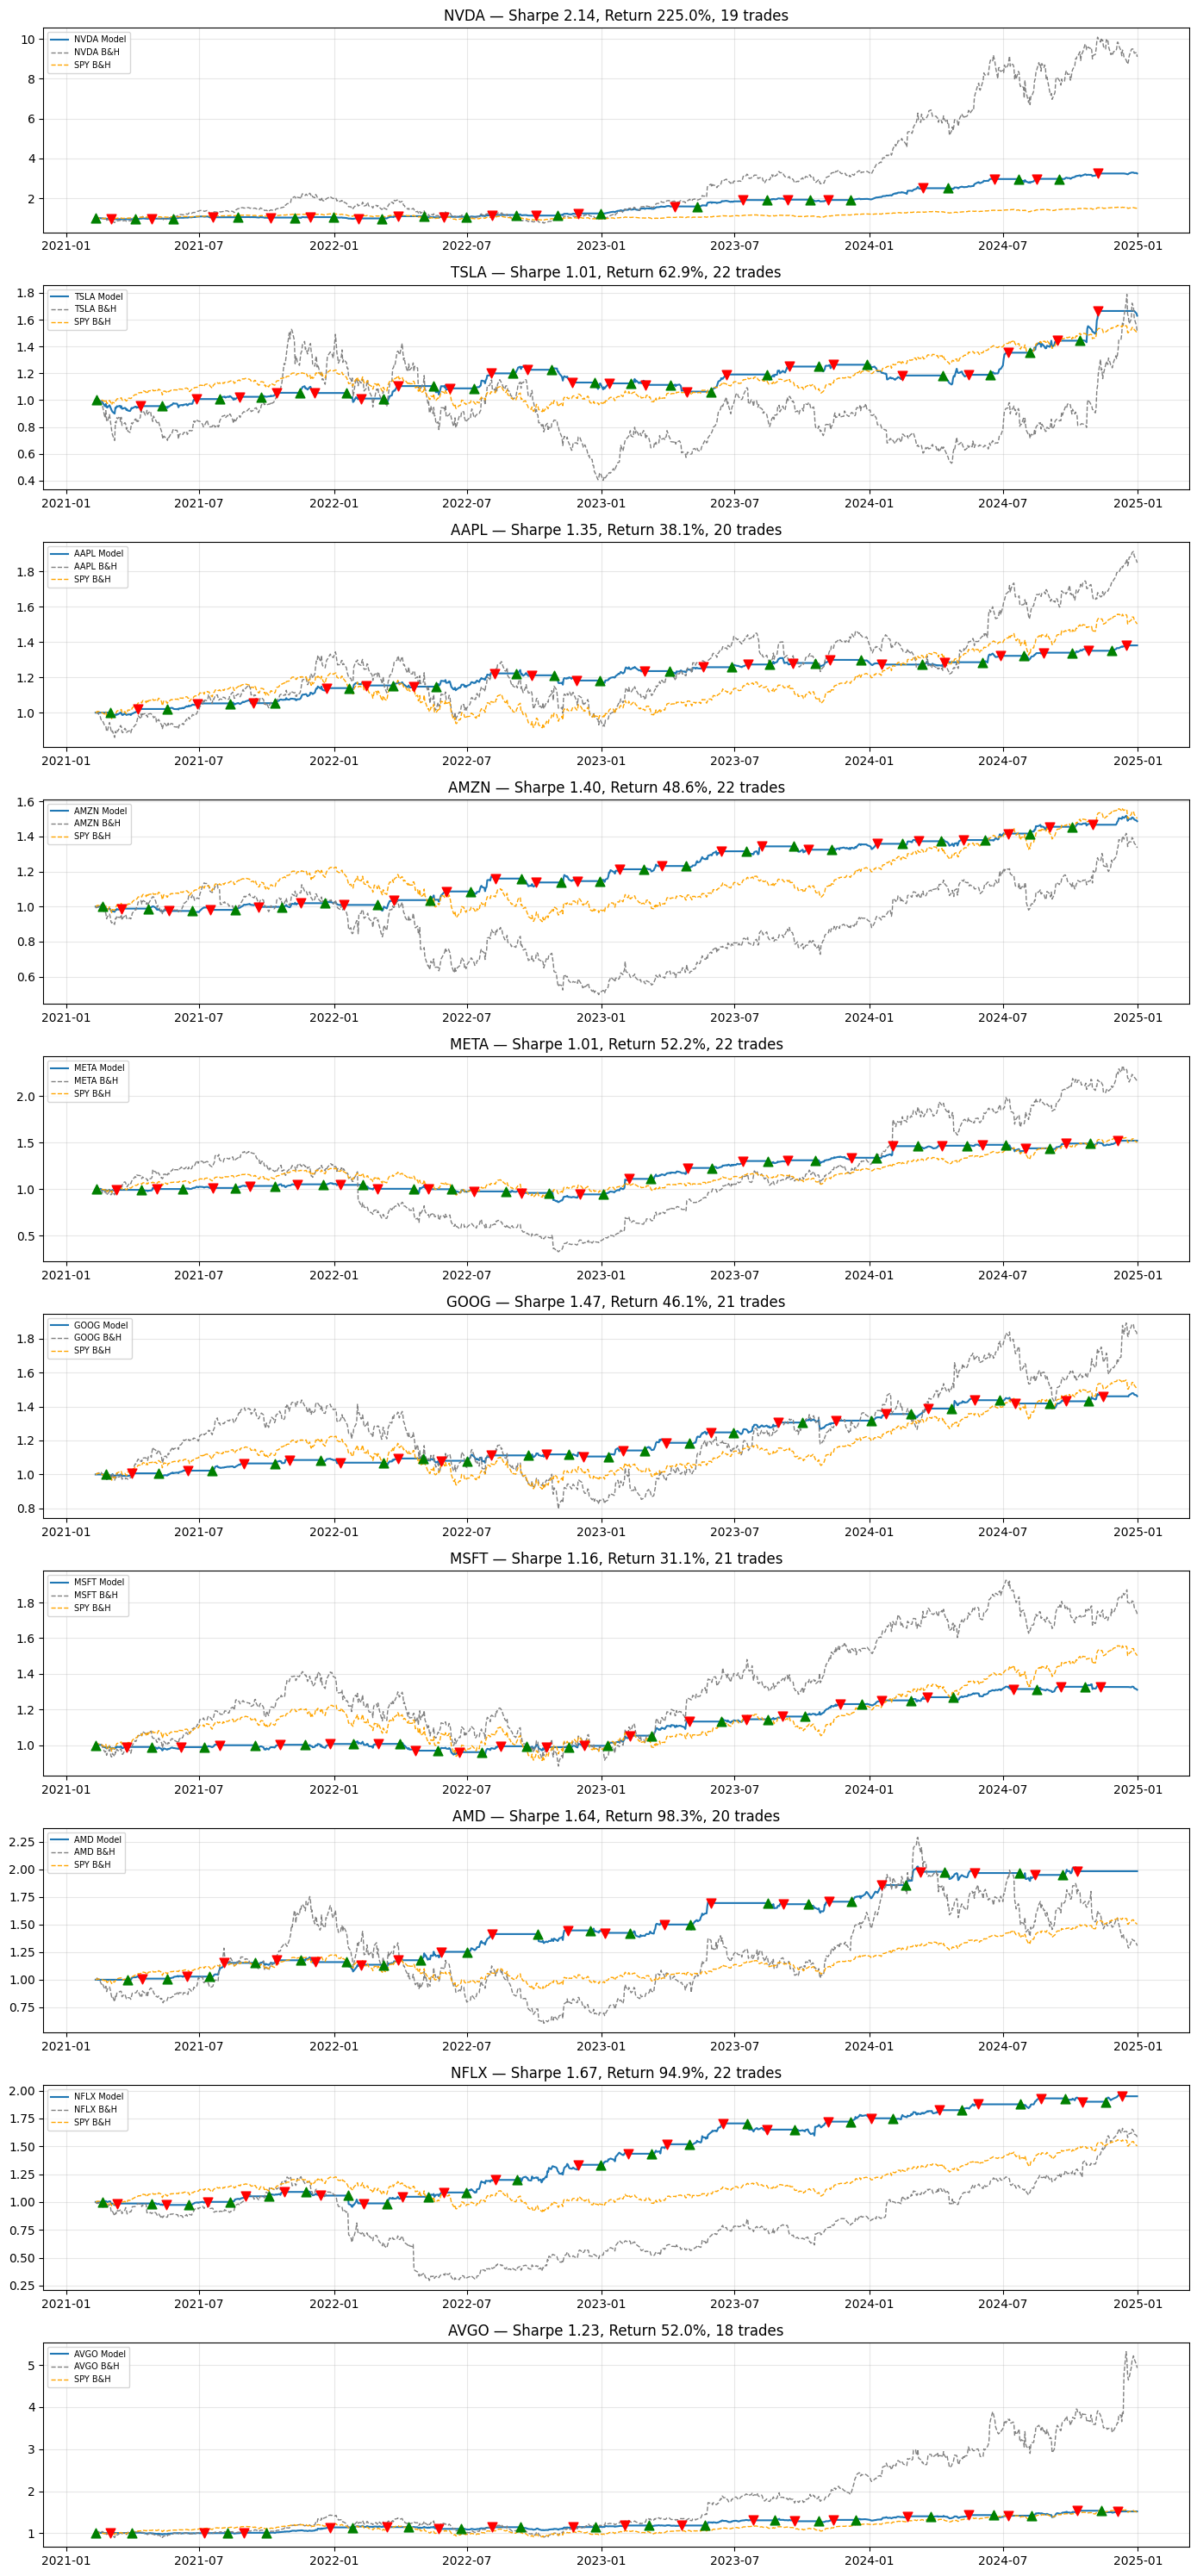

,Symbol,Return,Sharpe,Trades
0,NVDA,224.98%,2.14,19
1,TSLA,62.93%,1.01,22
2,AAPL,38.11%,1.35,20
3,AMZN,48.64%,1.40,22
4,META,52.19%,1.01,22
5,GOOG,46.06%,1.47,21
6,MSFT,31.08%,1.16,21
7,AMD,98.26%,1.64,20
8,NFLX,94.91%,1.67,22
9,AVGO,51.98%,1.23,18


In [4]:
# ══════════════════════════════════════════════════════════════════════════
# Evaluate each model: constrained equity curve + Sharpe ratio
# ══════════════════════════════════════════════════════════════════════════

INITIAL_CASH = config["initial_cash"]
WASH_SALE_DAYS = config.get("wash_sale_days", 30)
MIN_HOLD_DAYS = config.get("min_hold_days", 20)
MAX_HOLD_DAYS = config.get("max_hold_days", 150)
pos = config.get("position_sizing", {})
MAX_POSITION_PCT = pos.get("max_position_pct", 0.33)
CASH_RESERVE_PCT = pos.get("cash_reserve_pct", 0.10)


def apply_constraints(signals, min_hold_days=0, wash_sale_days=0, max_hold_days=0):
    out = signals.values.copy()
    dates = signals.index
    position = 0
    entry_idx = None
    last_sell_idx = None

    for i in range(len(out)):
        sig = out[i]
        if position == 1 and max_hold_days > 0 and entry_idx is not None:
            if (dates[i] - dates[entry_idx]).days >= max_hold_days:
                out[i] = "sell"
                position = 0
                last_sell_idx = i
                entry_idx = None
                continue
        if sig == "buy" and position == 0:
            if last_sell_idx is not None and (dates[i] - dates[last_sell_idx]).days < wash_sale_days:
                out[i] = "hold"
                continue
            position = 1
            entry_idx = i
        elif sig == "sell" and position == 1:
            if entry_idx is not None and (dates[i] - dates[entry_idx]).days < min_hold_days:
                out[i] = "hold"
                continue
            position = 0
            last_sell_idx = i
            entry_idx = None
        else:
            if (sig == "sell" and position == 0) or (sig == "buy" and position == 1):
                out[i] = "hold"
    return pd.Series(out, index=signals.index)


def simulate_equity(signals, prices, initial_cash=INITIAL_CASH):
    close = prices.values
    sigs = signals.values
    cash = float(initial_cash)
    shares = 0
    equity = np.empty(len(sigs))
    trades = []
    entry_idx = None

    for i in range(len(sigs)):
        p = close[i]
        portfolio_value = cash + shares * p
        if sigs[i] == "buy" and shares == 0:
            max_invest = portfolio_value * MAX_POSITION_PCT
            available = cash - portfolio_value * CASH_RESERVE_PCT
            invest_amount = min(max_invest, max(available, 0))
            shares = int(invest_amount // p)
            cash -= shares * p
            entry_idx = i
        elif sigs[i] == "sell" and shares > 0:
            cash += shares * p
            shares = 0
            if entry_idx is not None:
                trades.append((signals.index[entry_idx], signals.index[i]))
                entry_idx = None
        equity[i] = cash + shares * p
    return pd.Series(equity, index=signals.index), trades


# Evaluate each stock's model
summary = []
fig, axes = plt.subplots(len(WATCHLIST), 1, figsize=(14, 3 * len(WATCHLIST)), sharex=False)
if len(WATCHLIST) == 1:
    axes = [axes]

for ax, symbol in zip(axes, WATCHLIST):
    model = trained_models[symbol]

    # Rebuild the stock data for the sample period
    df_stock = common.fetch_ohlcv(symbol, start=START, end=END, provider=PROVIDER)
    df_stock = common.compute_indicators(df_stock, INDICATOR_SPEC)
    common_idx = df_stock.index.intersection(df_spy.index)
    df = pd.DataFrame(index=common_idx)
    df["close"] = df_stock.loc[common_idx, "close"]
    df["close_spy"] = df_spy.loc[common_idx, "close"]
    for col in FEATURE_COLUMNS:
        if col in RATIO_FEATURES:
            df[col] = df_stock.loc[common_idx, col] / df_spy.loc[common_idx, col].replace(0, np.nan)
        elif col in DIFF_FEATURES:
            df[col] = df_stock.loc[common_idx, col] - df_spy.loc[common_idx, col]
        else:
            df[col] = df_stock.loc[common_idx, col]
    df = df.dropna()

    signals = model.predict_bulk(df)
    constrained = apply_constraints(signals, MIN_HOLD_DAYS, WASH_SALE_DAYS, MAX_HOLD_DAYS)
    eq, trades = simulate_equity(constrained, df["close"])

    total_ret = eq.iloc[-1] / eq.iloc[0] - 1
    daily_rets = eq.pct_change().dropna()
    sharpe = daily_rets.mean() / daily_rets.std() * np.sqrt(252) if daily_rets.std() > 0 else 0

    # Plot
    norm_eq = eq / eq.iloc[0]
    bh = df["close"] / df["close"].iloc[0]
    spy_bh = df["close_spy"] / df["close_spy"].iloc[0]
    ax.plot(norm_eq.index, norm_eq, label=f"{symbol} Model", linewidth=1.5)
    ax.plot(bh.index, bh, label=f"{symbol} B&H", linestyle="--", color="gray", linewidth=1)
    ax.plot(spy_bh.index, spy_bh, label="SPY B&H", linestyle="--", color="orange", linewidth=1)
    buy_dates = [t[0] for t in trades]
    sell_dates = [t[1] for t in trades]
    if buy_dates:
        ax.scatter(buy_dates, norm_eq.loc[buy_dates], marker="^", color="green", s=60, zorder=5)
    if sell_dates:
        ax.scatter(sell_dates, norm_eq.loc[sell_dates], marker="v", color="red", s=60, zorder=5)
    ax.set_title(f"{symbol} — Sharpe {sharpe:.2f}, Return {total_ret:.1%}, {len(trades)} trades")
    ax.legend(loc="upper left", fontsize=7)
    ax.grid(True, alpha=0.3)

    summary.append({
        "Symbol": symbol, "Return": f"{total_ret:.2%}", "Sharpe": f"{sharpe:.2f}",
        "Trades": len(trades),
    })

plt.tight_layout()
plt.show()

pd.DataFrame(summary)

In [5]:
# ══════════════════════════════════════════════════════════════════════════
# Export all per-stock model artifacts
# ══════════════════════════════════════════════════════════════════════════

import glob

# Clean up old artifacts
old_artifacts = glob.glob(str(STRATEGY_DIR / f"{MODEL_NAME}-*-*.json"))
for path in old_artifacts:
    Path(path).unlink()
    print(f"  removed {Path(path).name}")

# Export each stock's model
for symbol, model in trained_models.items():
    artifact_name = f"{MODEL_NAME}-{symbol}"
    metadata = model.save(STRATEGY_DIR, artifact_name)
    artifacts = list(metadata.get("artifacts", {}).keys())
    print(f"Exported {symbol}: {artifact_name}-policy-metadata.json, {artifact_name}-rf-trees.json")

print(f"\nDone: {len(trained_models)} models exported to {STRATEGY_DIR}/")
print(f"\nNext steps:")
print(f"  cd {STRATEGY_DIR}")
print(f"  lean backtest .")
print(f"  python scripts/backtest_and_analyze.py --strategy renquant_201")

Exported NVDA: renquant-201-NVDA-policy-metadata.json, renquant-201-NVDA-rf-trees.json
Exported TSLA: renquant-201-TSLA-policy-metadata.json, renquant-201-TSLA-rf-trees.json
Exported AAPL: renquant-201-AAPL-policy-metadata.json, renquant-201-AAPL-rf-trees.json
Exported AMZN: renquant-201-AMZN-policy-metadata.json, renquant-201-AMZN-rf-trees.json
Exported META: renquant-201-META-policy-metadata.json, renquant-201-META-rf-trees.json
Exported GOOG: renquant-201-GOOG-policy-metadata.json, renquant-201-GOOG-rf-trees.json
Exported MSFT: renquant-201-MSFT-policy-metadata.json, renquant-201-MSFT-rf-trees.json
Exported AMD: renquant-201-AMD-policy-metadata.json, renquant-201-AMD-rf-trees.json
Exported NFLX: renquant-201-NFLX-policy-metadata.json, renquant-201-NFLX-rf-trees.json
Exported AVGO: renquant-201-AVGO-policy-metadata.json, renquant-201-AVGO-rf-trees.json

Done: 10 models exported to /Users/renhao/git/github/RenQuant/backtesting/renquant_201/

Next steps:
  cd /Users/renhao/git/github/R